# Exploratory Data Analysis (EDA)

This notebook explores the Panama electricity load dataset.
The goal is to understand temporal patterns, seasonality,
and key characteristics of the target variable before modeling.


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [63]:
import os
os.listdir("../data/raw")

['continuous dataset.csv',
 'test_dataframes.xlsx',
 'train_dataframes.xlsx',
 'weekly pre-dispatch forecast.csv']

In [64]:
data_path = "../data/raw/continuous dataset.csv"
df = pd.read_csv(data_path)

df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [65]:
df.shape

(48048, 17)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48048 entries, 0 to 48047
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    48048 non-null  object 
 1   nat_demand  48048 non-null  float64
 2   T2M_toc     48048 non-null  float64
 3   QV2M_toc    48048 non-null  float64
 4   TQL_toc     48048 non-null  float64
 5   W2M_toc     48048 non-null  float64
 6   T2M_san     48048 non-null  float64
 7   QV2M_san    48048 non-null  float64
 8   TQL_san     48048 non-null  float64
 9   W2M_san     48048 non-null  float64
 10  T2M_dav     48048 non-null  float64
 11  QV2M_dav    48048 non-null  float64
 12  TQL_dav     48048 non-null  float64
 13  W2M_dav     48048 non-null  float64
 14  Holiday_ID  48048 non-null  int64  
 15  holiday     48048 non-null  int64  
 16  school      48048 non-null  int64  
dtypes: float64(13), int64(3), object(1)
memory usage: 6.2+ MB


In [67]:
df.columns

Index(['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
       'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav',
       'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school'],
      dtype='object')

In [68]:
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

df.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [69]:
target = 'nat_demand'

In [70]:
df.isnull().sum().sort_values(ascending=False).head(10)

nat_demand    0
T2M_toc       0
QV2M_toc      0
TQL_toc       0
W2M_toc       0
T2M_san       0
QV2M_san      0
TQL_san       0
W2M_san       0
T2M_dav       0
dtype: int64

## Daily / Weekly Patterns

Electricity load typically shows strong daily and weekly seasonality.
We create time-based features (hour, weekday) for analysis.
# 1. Create time-based features from datetime index

In [71]:
# 1. Create time-based features from datetime index
df["hour"] = df.index.hour
df["weekday"] = df.index.weekday  # 0=Mon, 6=Sun
df["month"] = df.index.month


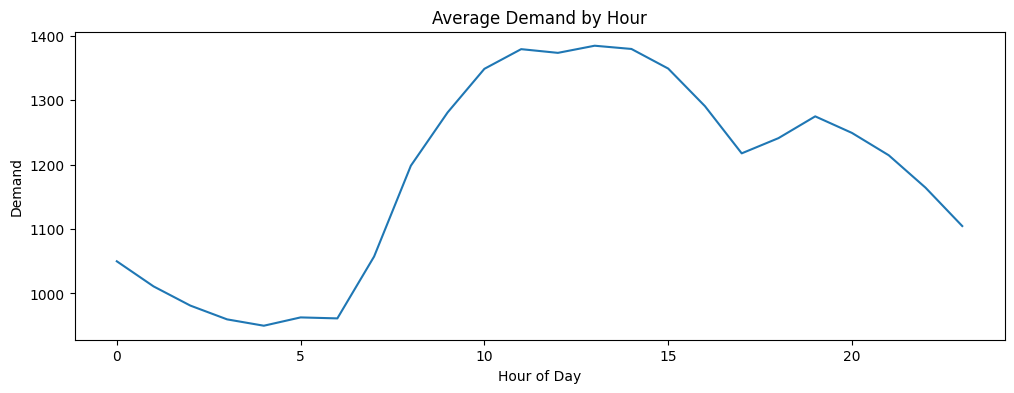

In [72]:
# 2. Average demand by hour (daily pattern)
plt.figure(figsize=(12, 4))
df.groupby("hour")[target].mean().plot()
plt.title("Average Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Demand")
plt.show()



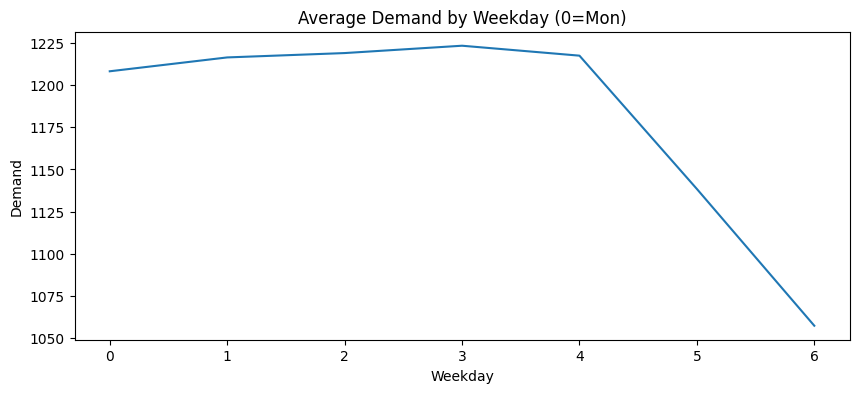

In [73]:
# 3. Average demand by weekday (weekly pattern)
plt.figure(figsize=(10, 4))
df.groupby("weekday")[target].mean().plot()
plt.title("Average Demand by Weekday (0=Mon)")
plt.xlabel("Weekday")
plt.ylabel("Demand")
plt.show()


## Relationship with Weather Features

check correlation between demand and weather variables.
This helps motivate using exogenous variables in forecasting models.


In [74]:
# 1. Correlation of all numeric features with the target
corr_with_target = df.corr(numeric_only=True)[target].sort_values(ascending=False)

# 2. Show top positive/negative correlations
corr_with_target.head(15), corr_with_target.tail(15)


(nat_demand    1.000000
 T2M_toc       0.652811
 T2M_dav       0.648279
 T2M_san       0.627024
 hour          0.453087
 W2M_san       0.191796
 TQL_san       0.119038
 W2M_toc       0.098435
 TQL_toc       0.073109
 TQL_dav       0.042037
 school        0.040044
 QV2M_san      0.022172
 month         0.006412
 QV2M_dav     -0.002117
 QV2M_toc     -0.036706
 Name: nat_demand, dtype: float64,
 hour          0.453087
 W2M_san       0.191796
 TQL_san       0.119038
 W2M_toc       0.098435
 TQL_toc       0.073109
 TQL_dav       0.042037
 school        0.040044
 QV2M_san      0.022172
 month         0.006412
 QV2M_dav     -0.002117
 QV2M_toc     -0.036706
 W2M_dav      -0.054802
 Holiday_ID   -0.129834
 holiday      -0.165673
 weekday      -0.226683
 Name: nat_demand, dtype: float64)

## Correlation Analysis (Heatmap)

Before building forecasting models, we examine the correlation
between electricity demand and other numerical variables.

This analysis helps:
- Identify variables strongly related to the target
- Detect redundant or highly correlated features
- Motivate feature selection and model design choices


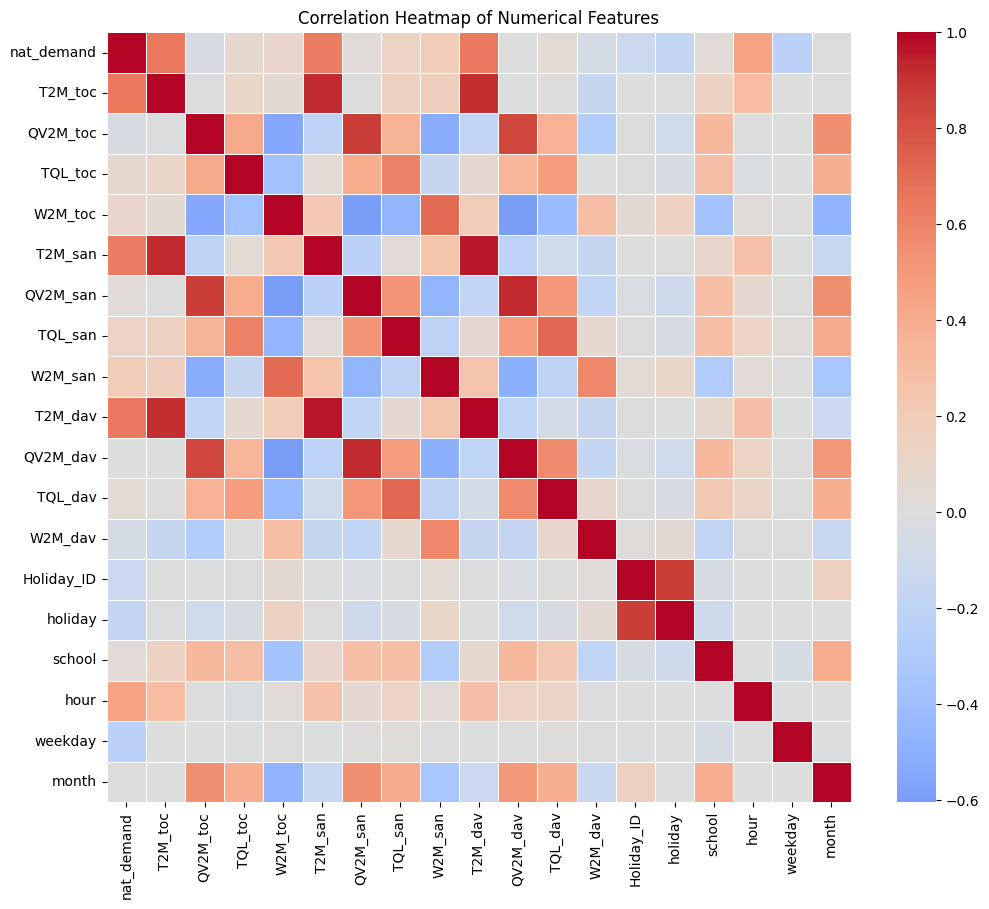

In [75]:
# Compute correlation matrix for numerical features only
corr_matrix = df.corr(numeric_only=True)

# Visualize correlation structure using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()


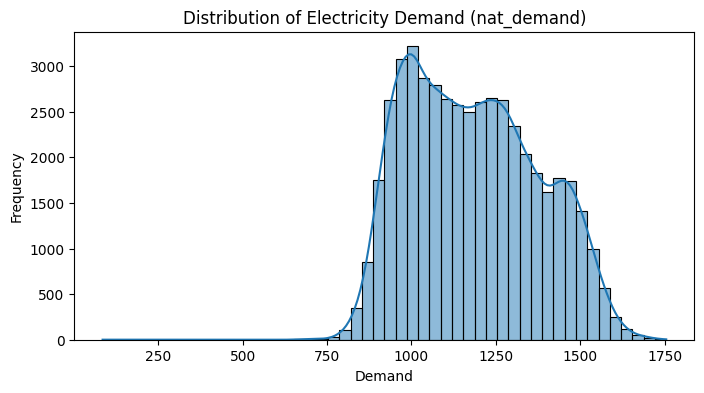

In [76]:
# ----------------------------------------
# Target Variable Distribution
# ----------------------------------------
# 목적:
# - electricity demand의 분포 형태 확인
# - 심한 왜도(skewness)나 이상치 존재 여부 점검
# - 정규화/스케일링 필요성 판단

plt.figure(figsize=(8, 4))
sns.histplot(df[target], bins=50, kde=True)
plt.title("Distribution of Electricity Demand (nat_demand)")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()


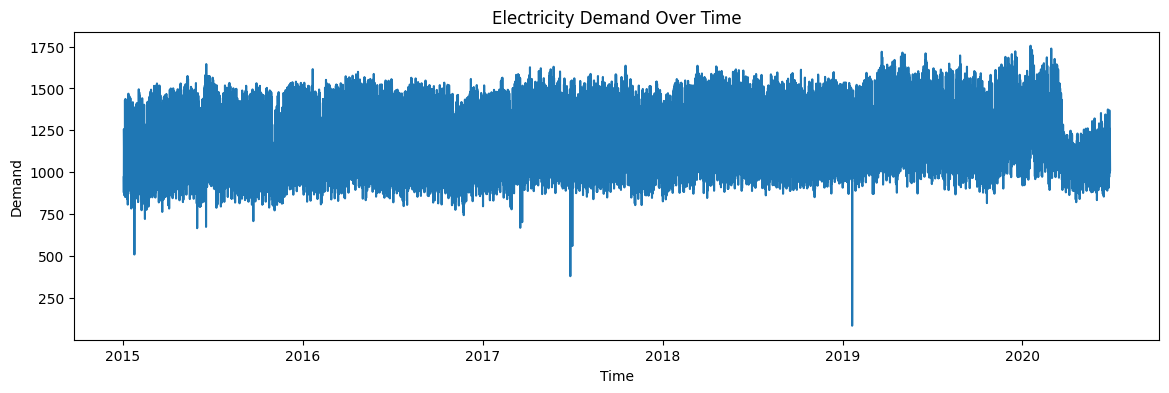

In [77]:
# ----------------------------------------
# Time Series Plot of Electricity Demand
# ----------------------------------------
# 목적:
# - 장기 추세(trend) 및 계절성(seasonality) 확인
# - 시간에 따른 변동성 변화 여부 파악
# - 시계열 모델(LSTM/CNN) 사용 타당성 시각적 근거 확보

plt.figure(figsize=(14, 4))
plt.plot(df.index, df[target])
plt.title("Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.show()


## EDA 요약

탐색적 데이터 분석(EDA)을 통해 다음과 같은 주요 특성을 확인하였다.

- 전력 수요(nat_demand)는 시간대(hour)에 따라 뚜렷한 일간 주기성을 보이며,
  오전~정오 시간대에 피크를 형성하고 야간 시간대에 감소하는 패턴이 반복된다.
- 요일(weekday)에 따른 평균 수요 차이가 존재하여,
  주중과 주말 간 전력 수요 행태가 다름을 확인하였다.
  이는 전력 수요 데이터가 주간 단위의 주기성을 가진 시계열임을 의미한다.
- 기온(T2M 계열) 등 기상 변수들은 전력 수요와 강한 양의 상관관계를 보이며,수요 예측에 중요한 설명력을 가질 수 있음을 시사한다.
- 일부 기상 변수들 간에는 높은 상관관계가 관찰되어,
  변수 간 중복성(redundancy)이 존재할 가능성이 있으며
  향후 변수 선택(feature selection) 또는 정규화 기법이 필요할 수 있다.

이러한 분석 결과를 바탕으로,
전력 수요 예측 문제는 명확한 시간적 의존성과 주기성을 가지는 시계열 문제로 정의할 수 있으며,
다음 단계에서는 데이터를 고정 길이의 시계열 윈도우 형태로 변환하여
LSTM, 1D CNN과 같은 시퀀스 기반 딥러닝 모델을 적용한다.
